In [65]:
import json

import numpy as np


def load_binary(filename: str) -> bytes:
    data = open(filename, "rb").read()
    # return np.frombuffer(data, dtype=np.uint8)
    return data


data_all_ones = load_binary("all_ones.bin")
data_all_zeros = load_binary("all_zeros.bin")
data_half_zeros_half_ones = load_binary("half_zeros_half_ones.bin")
data_ramp = load_binary("ramp.bin")
data_toggle = load_binary("toggle.bin")
data_real = load_binary("../latest.bin")

config = json.load(open("config.json"))

In [66]:
assert len(data_all_ones) == len(data_all_zeros) == len(data_half_zeros_half_ones) == len(data_ramp) == len(data_toggle)

num_bytes = len(data_all_ones)

num_bytes

80040

In [67]:
fifo_depth = config["fpga"]["fifo_depth"]
num_shots = config["fpga"]["num_shots"]
num_frames = config["num_frames"]
lvds_lanes = config["fpga"]["lvds_lanes"]
afe_clk_hispeed = config["fpga"]["afe_clk_hispeed"]

fifo_depth, num_shots, num_frames, lvds_lanes, afe_clk_hispeed

(2048, 10, 1, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], True)

In [68]:
bytes_per_shot = fifo_depth * 2 * 10 / 8 * len(lvds_lanes)

bytes_per_shot, bytes_per_shot * num_shots * num_frames

(81920.0, 819200.0)

In [69]:
np.unpackbits(np.frombuffer(data_all_ones, dtype=np.uint8), axis=-1, bitorder='big').reshape((len(lvds_lanes), -1))

array([[0, 0, 0, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(16, 40020), dtype=uint8)

In [70]:
def hexdump(data: np.ndarray | bytes, binary: bool = False):
    for i in range(0, len(data), 16 if not binary else 8):
        chunk = data[i:i+16]
        if not binary:
            hex_bytes = ' '.join(f'{b:02X}' for b in chunk)
        else:
            hex_bytes = ' '.join(f'{b:08b}' for b in chunk)
        ascii_bytes = ''.join((chr(b) if 32 <= b < 127 else '.') for b in chunk)
        print(f'{i:08X}  {hex_bytes:<48}  |{ascii_bytes}|')

# START_IDX = 3190 * 10 // 8
# END_IDX = 3210 * 10 // 8
START_IDX = 0
END_IDX = 32

print("All Ones:")
hexdump(data_all_ones[START_IDX:END_IDX])
print("All Zeros:")
hexdump(data_all_zeros[START_IDX:END_IDX])
print("Half Zeros Half Ones:")
hexdump(data_half_zeros_half_ones[START_IDX:END_IDX])
print("Ramp:")
hexdump(data_ramp[START_IDX:END_IDX])
print("Toggle:")
hexdump(data_toggle[START_IDX:END_IDX])
print("Real Data:")
hexdump(data_real[START_IDX:END_IDX])

All Ones:
00000000  00 00 FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000010  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
All Zeros:
00000000  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   |................|
00000010  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   |................|
Half Zeros Half Ones:
00000000  00 00 E0 F8 3E 0F 83 E0 F8 3E 0F 83 E0 F8 3E 0F   |....>....>....>.|
00000010  83 E0 F8 3E 0F 83 E0 F8 3E 0F 83 E0 F8 3E 0F 83   |...>....>....>..|
Ramp:
00000000  00 00 4C D3 74 ED 37 50 D3 F5 1D 47 01 00 30 30   |..L.t.7P...G..00|
00000010  08 05 01 00 70 18 09 02 00 B0 28 0D 03 00 F0 38   |....p.....(....8|
Toggle:
00000000  00 00 00 FF C0 0F FC 00 FF C0 00 00 00 FF C0 0F   |................|
00000010  FC 00 FF C0 0F FC 00 FF C0 0F FC 00 FF C0 0F FC   |................|
Real Data:
00000000  00 00 F9 FF FF 9F FF FB 00 3F B0 03 FB 00 7F C0   |.........?......|
00000010  07 FB 00 7F C0 07 FD 00 70 60 17 16 03 8D D0 04   |..

In [71]:
hexdump(data_all_ones[:32])
hexdump(data_all_ones[:32])

00000000  00 00 FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000010  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000000  00 00 FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000010  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|


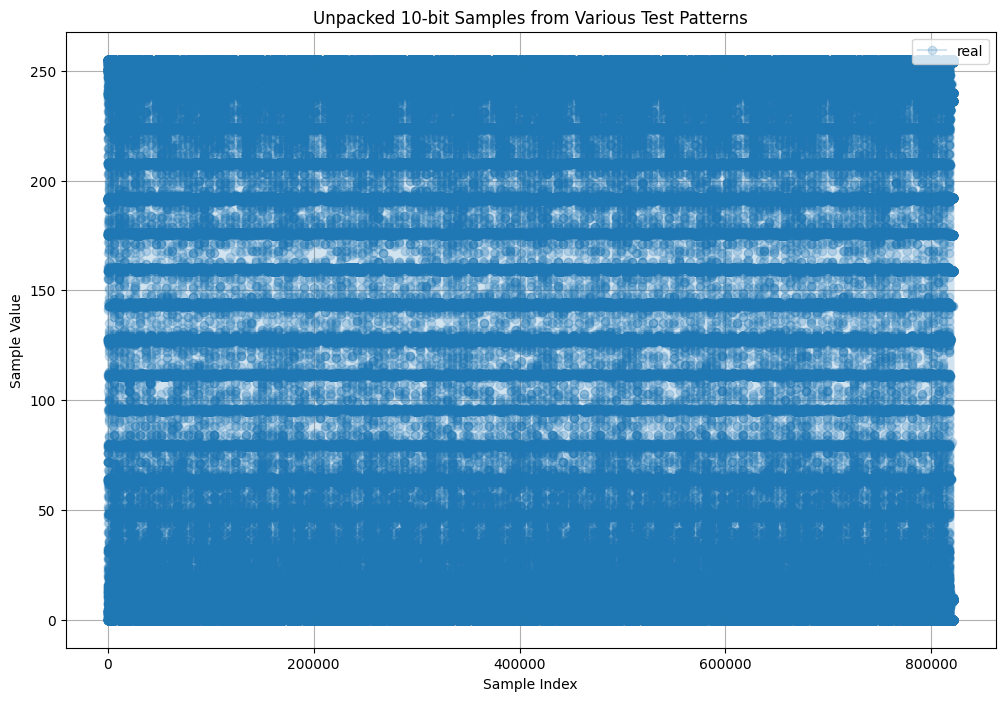

In [72]:
import matplotlib.pyplot as plt
# %matplotlib widget


plt.figure(figsize=(12, 8))

for name, data in [
    # ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    # ("half_zeros_half_ones", data_half_zeros_half_ones),
    # ("ramp", data_ramp),
    # ("toggle", data_toggle),
    ("real", data_real),
]:

    plt.plot(np.frombuffer(data_real, np.uint8), 'o-', alpha=0.2, label=f"{name}")

plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Sample Value")
# plt.xlim(1000, 1110)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [73]:
# print(f"{0xE0:08b}{0xF8:08b}{0x3E:08b}{0x0F:08b}{0x83:08b}")
print(f"{0xF8:08b} {0x3E:08b} {0x0F:08b} {0x83:08b} {0xE0:08b}")

11111000 00111110 00001111 10000011 11100000


In [74]:
from parser import parse_bitstream_numba, parse_bitstream_numpy

# Numba warmup
_ = parse_bitstream_numba(np.frombuffer(data_all_ones, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))

In [75]:
# %%timeit
# _ = parse_bitstream_numpy(data_all_zeros, num_shots, num_frames, fifo_depth, lvds_lanes)

In [76]:
# %%timeit
# _ = parse_bitstream_numba(np.frombuffer(data_all_ones, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))

In [77]:
# import matplotlib.pyplot as plt
# # %matplotlib widget


# plt.figure(figsize=(12, 8))

# for name, data in [
#     # ("all_ones", data_all_ones),
#     # ("all_zeros", data_all_zeros),
#     # ("half_zeros_half_ones", data_half_zeros_half_ones),
#     # ("ramp", data_ramp),
#     # ("toggle", data_toggle),
#     ("real", data_real),
# ]:
#     # data_parsed = parse_bitstream_numba(np.frombuffer(data, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))
#     data_parsed = parse_bitstream_numpy(np.frombuffer(data, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))

#     for frame in range(data_parsed.shape[0]):
#     # for frame in range(1):
#         for channel in range(data_parsed.shape[2]):
#         # for channel in range(1):
#             plt.plot(data_parsed[frame, 0, channel], 'o-', alpha=0.2, label=f"{name} Frame {frame} Channel {channel}")

# plt.title("Unpacked 10-bit Samples from Various Test Patterns")
# plt.xlabel("Sample Index")
# plt.ylabel("Sample Value")
# # plt.xlim(1000, 1110)
# plt.legend(loc='upper right')
# plt.grid()
# plt.show()

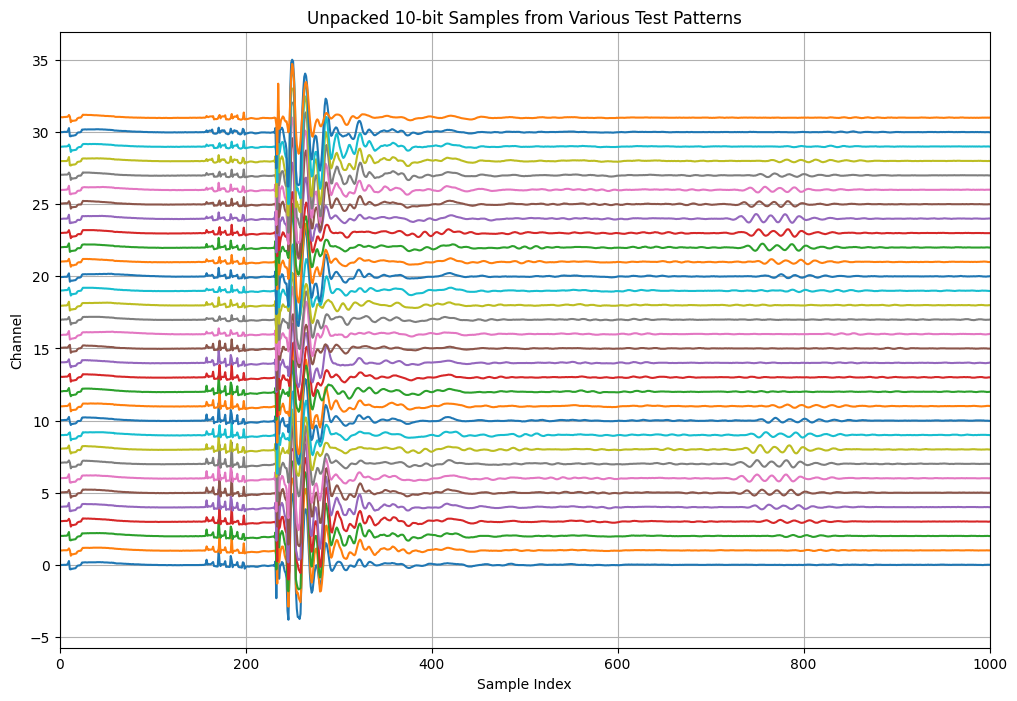

In [84]:
from parser import parse_bitstream_original, parse_bitstream_numba

rx_mapping = [
            29,
            9,
            27,
            7,
            25,
            4,
            23,
            11,
            21,
            5,
            26,
            3,
            30,
            1,
            28,
            0,
            31,
            2,
            17,
            15,
            16,
            14,
            19,
            13,
            18,
            12,
            20,
            10,
            22,
            8,
            24,
            6,
        ]

plt.figure(figsize=(12, 8))

for name, data in [
    # ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    # ("half_zeros_half_ones", data_half_zeros_half_ones),
    # ("ramp", data_ramp),
    # ("toggle", data_toggle),
    ("real", data_real),
]:
    data_headers_removed = []
    for i in range(len(data)):
        if (i % (1000 + 2)) < 2:
            continue
        data_headers_removed.append(data[i])

    data = bytes(data_headers_removed)

    samples = parse_bitstream_original(data, dbg_msgs=False, read_size_samples=fifo_depth, n_activ_ch=len(lvds_lanes)*2)
    # plt.plot(samples[0], 'o-', label=name, alpha=0.5)

    for i, sample in enumerate(samples):
        # plt.plot(sample / 1000 + i, 'o-', label=f"{name} Channel {i}", alpha=0.5)
        plt.plot((sample - sample.mean()) / 100 + i)
    # plt.imshow(np.array(samples), aspect='auto', extent=[0, fifo_depth, 0, len(samples)], cmap='viridis')


plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
# plt.ylabel("Sample Value")
plt.ylabel("Channel")
plt.xlim(0, 1000)
# plt.legend(loc='upper right')
plt.grid()
plt.show()

(10, 32, 2047)


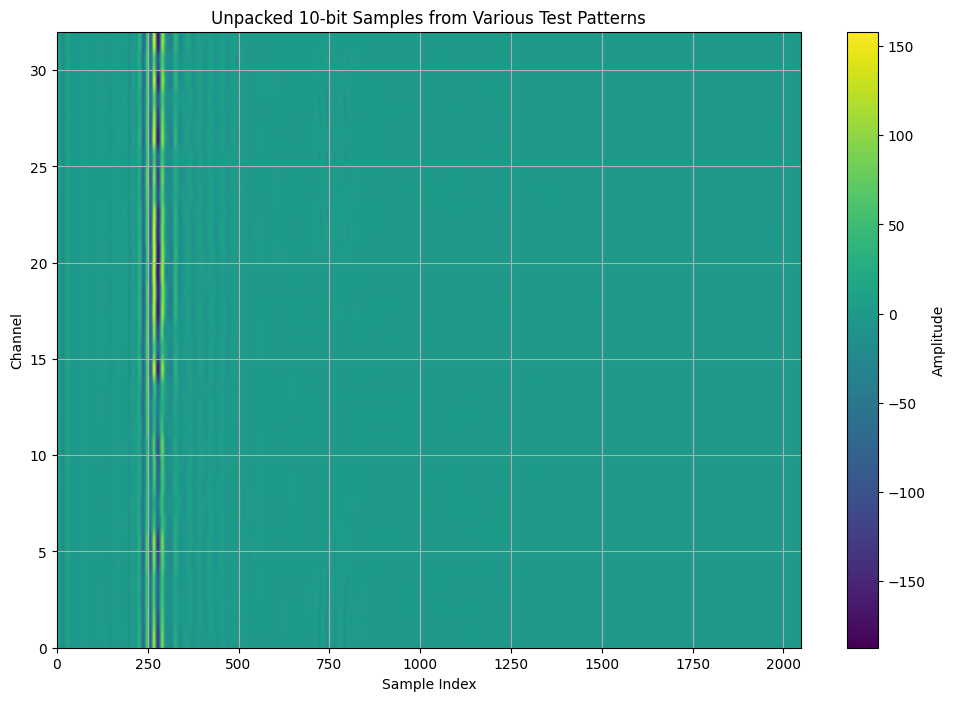

In [92]:
import scipy.signal as ss

plt.figure(figsize=(12, 8))

for name, data in [
    # ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    # ("half_zeros_half_ones", data_half_zeros_half_ones),
    # ("ramp", data_ramp),
    # ("toggle", data_toggle),
    ("real", data_real),
]:
    data_headers_removed = []
    for i in range(len(data)):
        if (i % (1000 + 2)) < 2:
            continue
        data_headers_removed.append(data[i])

    n_shots_rx = num_shots * num_frames
    bytes_per_shot = len(data_headers_removed) // n_shots_rx

    data =  np.frombuffer(bytes(data_headers_removed), dtype=np.uint8).reshape((n_shots_rx, bytes_per_shot))

    def parse_shot(data_shot):
        return parse_bitstream_original(data_shot, dbg_msgs=False, read_size_samples=fifo_depth, n_activ_ch=len(lvds_lanes)*2)

    data = np.apply_along_axis(parse_shot, 1, data)
    print(data.shape)  # (n_shots_rx, n_channels, fifo_depth)
    data = data[:, rx_mapping, :]

    def filter_shot(data_shot):
        f_low = 0.55 * 2.25e6
        f_high = 1.45 * 2.25e6
        f_sampling = 60e6 if afe_clk_hispeed else 30e6

        b, a = ss.butter(4, [f_low / (0.5 * f_sampling), f_high / (0.5 * f_sampling)], btype='band')

        return ss.filtfilt(b, a, data_shot, axis=-1)
    
    data_filtered = np.apply_along_axis(filter_shot, 2, data)

    # samples = parse_bitstream_original(data, dbg_msgs=False, read_size_samples=fifo_depth, n_activ_ch=len(lvds_lanes)*2)
    # plt.plot(samples[0], 'o-', label=name, alpha=0.5)

    # for i, channel in enumerate(data[5]):
    #     # plt.plot(sample / 1000 + i, 'o-', label=f"{name} Channel {i}", alpha=0.5)
    #     plt.plot((channel - channel.mean()) / 10 + i)
    #     plt.plot((data_filtered[5, i] - data_filtered[5, i].mean()) / 10 + i, alpha=0.5)
    plt.imshow(data_filtered[5], aspect='auto', extent=[0, fifo_depth, 0, len(samples)], cmap='viridis')


plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
# plt.ylabel("Sample Value")
plt.ylabel("Channel")
plt.colorbar(label='Amplitude')
# plt.xlim(0, 1000)
# plt.legend(loc='upper right')
plt.grid()
plt.show()